In [113]:
import pandas as pd
import sqlite3


In [114]:
conn = sqlite3.connect('churn.db')

In [115]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.shape)

(7043, 21)


In [116]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [117]:
df.to_sql('customers', conn, if_exists='replace', index=False)

7043

In [118]:
pd.read_sql("SELECT * FROM customers LIMIT 5;", conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [119]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [120]:
df.shape

(7043, 21)

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [122]:
query = """
SELECT Churn, COUNT(*) as total_customers
FROM customers
GROUP BY Churn;
"""

pd.read_sql(query, conn)

,Churn,total_customers
0,No,5174
1,Yes,1869


In [123]:
query = """
SELECT COUNT(*) as blank_totalcharges
FROM customers
WHERE TotalCharges = ' ';
"""

pd.read_sql(query, conn)

,blank_totalcharges
0,11


In [124]:
query = """
SELECT *
FROM customers
WHERE TotalCharges = ' ';
"""

pd.read_sql(query, conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
1,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
2,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
3,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
4,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
5,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
6,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
7,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
8,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
9,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [125]:
conn.execute("""
UPDATE customers
SET TotalCharges = '0'
WHERE TotalCharges = ' ';
""")

conn.commit()

In [126]:
query = """
SELECT COUNT(*) as remaining_blanks
FROM customers
WHERE TotalCharges = ' ';
"""

pd.read_sql(query, conn)

,remaining_blanks
0,0


In [127]:
df_clean = pd.read_sql("SELECT * FROM customers;", conn)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"])
df_clean.to_sql("customers", conn, if_exists="replace", index=False)

7043

In [128]:
df_check = pd.read_sql("SELECT * FROM customers LIMIT 5;", conn)

print(df_check.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [129]:
pd.read_sql("""
SELECT AVG(MonthlyCharges) as avg_monthly_charge
FROM customers;
""", conn)

,avg_monthly_charge
0,64.761692


In [130]:
pd.read_sql("""
SELECT AVG(tenure) as avg_tenure
FROM customers;
""", conn)

,avg_tenure
0,32.371149


In [131]:
pd.read_sql("""
SELECT Contract, COUNT(*) as total
FROM customers
GROUP BY Contract;
""", conn)

,Contract,total
0,Month-to-month,3875
1,One year,1473
2,Two year,1695


In [132]:
clean_df = pd.read_sql("SELECT * FROM customers;", conn)

clean_df.to_csv("cleaned_customers.csv", index=False)

In [133]:
conn.execute("DROP TABLE IF EXISTS features")
conn.commit()
print("Clean slate — ready to create features table")

Clean slate — ready to create features table


In [134]:
conn.execute("""
CREATE TABLE features AS
SELECT
  customerID,

  -- Tenure group: how long has the customer been with us?
  CASE
    WHEN tenure <= 12 THEN 'new'
    WHEN tenure <= 36 THEN 'mid'
    ELSE 'loyal'
  END AS tenure_group,

  -- Monthly charge tier: how much are they paying?
  CASE
    WHEN MonthlyCharges < 35 THEN 'low'
    WHEN MonthlyCharges < 65 THEN 'medium'
    ELSE 'high'
  END AS charge_tier,

  MonthlyCharges,
  CAST(TotalCharges AS FLOAT) AS TotalCharges,
  tenure,
  Contract,
  PaymentMethod,

  -- Target label: 1 = churned, 0 = stayed
  CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END AS churn_label

FROM customers;
""")
conn.commit()
print("features table created successfully")

features table created successfully


In [135]:
df_features = pd.read_sql("SELECT * FROM features LIMIT 5;", conn)
print(df_features)

   customerID tenure_group charge_tier  MonthlyCharges  TotalCharges  tenure  \
0  7590-VHVEG          new         low           29.85         29.85       1   
1  5575-GNVDE          mid      medium           56.95       1889.50      34   
2  3668-QPYBK          new      medium           53.85        108.15       2   
3  7795-CFOCW        loyal      medium           42.30       1840.75      45   
4  9237-HQITU          new        high           70.70        151.65       2   

         Contract              PaymentMethod  churn_label  
0  Month-to-month           Electronic check            0  
1        One year               Mailed check            0  
2  Month-to-month               Mailed check            1  
3        One year  Bank transfer (automatic)            0  
4  Month-to-month           Electronic check            1  


In [136]:
pd.read_sql("SELECT COUNT(*) as total_rows FROM features;", conn)

,total_rows
0,7043


In [137]:
pd.read_sql("""
SELECT tenure_group, COUNT(*) as count
FROM features
GROUP BY tenure_group
ORDER BY count DESC;
""", conn)

,tenure_group,count
0,loyal,3001
1,new,2186
2,mid,1856


In [138]:
pd.read_sql("""
SELECT charge_tier, COUNT(*) as count
FROM features
GROUP BY charge_tier
ORDER BY count DESC;
""", conn)

,charge_tier,count
0,high,3904
1,low,1731
2,medium,1408


In [139]:
pd.read_sql("""
SELECT
  tenure_group,
  COUNT(*) as total,
  SUM(churn_label) as churned,
  ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) as churn_rate_percent
FROM features
GROUP BY tenure_group
ORDER BY churn_rate_percent DESC;
""", conn)

,tenure_group,total,churned,churn_rate_percent
0,new,2186,1037,47.44
1,mid,1856,474,25.54
2,loyal,3001,358,11.93


In [140]:
pd.read_sql("""
SELECT
  charge_tier,
  COUNT(*) as total,
  SUM(churn_label) as churned,
  ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) as churn_rate_percent
FROM features
GROUP BY charge_tier
ORDER BY churn_rate_percent DESC;
""", conn)

,charge_tier,total,churned,churn_rate_percent
0,high,3904,1355,34.71
1,medium,1408,326,23.15
2,low,1731,188,10.86


In [141]:
pd.read_sql("""
SELECT
  Contract,
  COUNT(*) as total,
  SUM(churn_label) as churned,
  ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) as churn_rate_percent
FROM features
GROUP BY Contract
ORDER BY churn_rate_percent DESC;
""", conn)

,Contract,total,churned,churn_rate_percent
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [142]:
df_features_full = pd.read_sql("SELECT * FROM features;", conn)
df_features_full.to_csv("features_engineered.csv", index=False)
print(f"Exported {len(df_features_full)} rows to features_engineered.csv")
print(df_features_full.shape)
print(df_features_full.columns.tolist())

Exported 7043 rows to features_engineered.csv
(7043, 9)
['customerID', 'tenure_group', 'charge_tier', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Contract', 'PaymentMethod', 'churn_label']


In [143]:
from google.colab import files
files.download("features_engineered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [144]:
# Count how many services each customer has

# Fix: Recreate features table with service_count already in it

conn.execute("DROP TABLE IF EXISTS features")

conn.execute("""
CREATE TABLE features AS
SELECT
  c.customerID,

  CASE
    WHEN c.tenure <= 12 THEN 'new'
    WHEN c.tenure <= 36 THEN 'mid'
    ELSE 'loyal'
  END AS tenure_group,

  CASE
    WHEN c.MonthlyCharges < 35 THEN 'low'
    WHEN c.MonthlyCharges < 65 THEN 'medium'
    ELSE 'high'
  END AS charge_tier,

  c.MonthlyCharges,
  CAST(c.TotalCharges AS FLOAT) AS TotalCharges,
  c.tenure,
  c.Contract,
  c.PaymentMethod,

  CASE WHEN c.Churn = 'Yes' THEN 1 ELSE 0 END AS churn_label,

  (CASE WHEN c.PhoneService='Yes' THEN 1 ELSE 0 END) +
  (CASE WHEN c.MultipleLines='Yes' THEN 1 ELSE 0 END) +
  (CASE WHEN c.InternetService!='No' THEN 1 ELSE 0 END) +
  (CASE WHEN c.OnlineSecurity='Yes' THEN 1 ELSE 0 END) +
  (CASE WHEN c.TechSupport='Yes' THEN 1 ELSE 0 END) +
  (CASE WHEN c.StreamingTV='Yes' THEN 1 ELSE 0 END) AS service_count

FROM customers c
""")

conn.commit()
print("features table recreated with service_count")


features table recreated with service_count


In [145]:
# Check the result

pd.read_sql("""
SELECT customerID, tenure_group, charge_tier, service_count, churn_label
FROM features
LIMIT 10;
""", conn)

,customerID,tenure_group,charge_tier,service_count,churn_label
0,7590-VHVEG,new,low,1,0
1,5575-GNVDE,mid,medium,3,0
2,3668-QPYBK,new,medium,3,1
3,7795-CFOCW,loyal,medium,3,0
4,9237-HQITU,new,high,2,1
5,9305-CDSKC,new,high,4,1
6,1452-KIOVK,mid,high,4,0
7,6713-OKOMC,new,low,2,0
8,7892-POOKP,mid,high,5,1
9,6388-TABGU,loyal,medium,3,0


In [146]:
# Churn rate by contract type

pd.read_sql("""
SELECT Contract,
       COUNT(*) as total_customers,
       SUM(churn_label) as churned,
       ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) as churn_rate_pct
FROM features
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
""", conn)

,Contract,total_customers,churned,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [147]:
# Churn rate by tenure group

pd.read_sql("""
SELECT tenure_group,
       COUNT(*) as total_customers,
       SUM(churn_label) as churned,
       ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) as churn_rate_pct
FROM features
GROUP BY tenure_group
ORDER BY churn_rate_pct DESC;
""", conn)

,tenure_group,total_customers,churned,churn_rate_pct
0,new,2186,1037,47.44
1,mid,1856,474,25.54
2,loyal,3001,358,11.93


In [148]:
# Churn rate by charge tier

pd.read_sql("""
SELECT charge_tier,
       COUNT(*) as total_customers,
       SUM(churn_label) as churned,
       ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) as churn_rate_pct
FROM features
GROUP BY charge_tier
ORDER BY churn_rate_pct DESC;
""", conn)

,charge_tier,total_customers,churned,churn_rate_pct
0,high,3904,1355,34.71
1,medium,1408,326,23.15
2,low,1731,188,10.86


In [149]:
#Churn rate by service count

pd.read_sql("""
SELECT service_count,
       COUNT(*) as total_customers,
       SUM(churn_label) as churned,
       ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) as churn_rate_pct
FROM features
GROUP BY service_count
ORDER BY service_count;
""", conn)

,service_count,total_customers,churned,churn_rate_pct
0,1,1355,179,13.21
1,2,1329,439,33.03
2,3,1542,578,37.48
3,4,1488,466,31.32
4,5,946,173,18.29
5,6,383,34,8.88


In [150]:
#Export final feature table

df_features = pd.read_sql("SELECT * FROM features", conn)
df_features.to_csv('features_engineered.csv', index=False)

print("Shape:", df_features.shape)
print("Columns:", df_features.columns.tolist())
df_features.head()

Shape: (7043, 10)
Columns: ['customerID', 'tenure_group', 'charge_tier', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Contract', 'PaymentMethod', 'churn_label', 'service_count']


,customerID,tenure_group,charge_tier,MonthlyCharges,TotalCharges,tenure,Contract,PaymentMethod,churn_label,service_count
0,7590-VHVEG,new,low,29.85,29.85,1,Month-to-month,Electronic check,0,1
1,5575-GNVDE,mid,medium,56.95,1889.50,34,One year,Mailed check,0,3
2,3668-QPYBK,new,medium,53.85,108.15,2,Month-to-month,Mailed check,1,3
3,7795-CFOCW,loyal,medium,42.30,1840.75,45,One year,Bank transfer (automatic),0,3
4,9237-HQITU,new,high,70.70,151.65,2,Month-to-month,Electronic check,1,2


In [151]:
#  Check the file is available

import os
print(os.path.exists('features_engineered.csv'))  # Should print True

True


In [152]:
# Import libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("All libraries imported")

All libraries imported


In [153]:
#  Load the CSV

df = pd.read_csv('features_engineered.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (7043, 10)
Columns: ['customerID', 'tenure_group', 'charge_tier', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Contract', 'PaymentMethod', 'churn_label', 'service_count']


,customerID,tenure_group,charge_tier,MonthlyCharges,TotalCharges,tenure,Contract,PaymentMethod,churn_label,service_count
0,7590-VHVEG,new,low,29.85,29.85,1,Month-to-month,Electronic check,0,1
1,5575-GNVDE,mid,medium,56.95,1889.50,34,One year,Mailed check,0,3
2,3668-QPYBK,new,medium,53.85,108.15,2,Month-to-month,Mailed check,1,3
3,7795-CFOCW,loyal,medium,42.30,1840.75,45,One year,Bank transfer (automatic),0,3
4,9237-HQITU,new,high,70.70,151.65,2,Month-to-month,Electronic check,1,2


In [154]:
#  Check for nulls

print(df.isnull().sum())

customerID        0
tenure_group      0
charge_tier       0
MonthlyCharges    0
TotalCharges      0
tenure            0
Contract          0
PaymentMethod     0
churn_label       0
service_count     0
dtype: int64


In [155]:
df = df.dropna()
print("After dropna:", df.shape)

After dropna: (7043, 10)


In [156]:
#  Encode categorical columns into numbers

le = LabelEncoder()

for col in ['tenure_group', 'charge_tier', 'Contract', 'PaymentMethod']:
    df[col] = le.fit_transform(df[col])
    print(f"{col} encoded")

df.head()

tenure_group encoded
charge_tier encoded
Contract encoded
PaymentMethod encoded


,customerID,tenure_group,charge_tier,MonthlyCharges,TotalCharges,tenure,Contract,PaymentMethod,churn_label,service_count
0,7590-VHVEG,2,1,29.85,29.85,1,0,2,0,1
1,5575-GNVDE,1,2,56.95,1889.50,34,1,3,0,3
2,3668-QPYBK,2,2,53.85,108.15,2,0,3,1,3
3,7795-CFOCW,0,2,42.30,1840.75,45,1,0,0,3
4,9237-HQITU,2,0,70.70,151.65,2,0,2,1,2


In [157]:
# Define X and y

X = df.drop(['customerID', 'churn_label'], axis=1)
y = df['churn_label']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

X shape: (7043, 8)
y shape: (7043,)
Churn distribution:
 churn_label
0    5174
1    1869
Name: count, dtype: int64


In [158]:
#  Split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


In [159]:
#  Train Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Logistic Regression trained")
print("Train accuracy:", round(lr.score(X_train, y_train), 4))
print("Test accuracy:", round(lr.score(X_test, y_test), 4))

Logistic Regression trained
Train accuracy: 0.7856
Test accuracy: 0.8034


In [160]:
#  Train Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest trained")
print("Train accuracy:", round(rf.score(X_train, y_train), 4))
print("Test accuracy:", round(rf.score(X_test, y_test), 4))

Random Forest trained
Train accuracy: 0.9943
Test accuracy: 0.7906


In [161]:
# Full evaluation report

print("=" * 40)
print("LOGISTIC REGRESSION REPORT")
print("=" * 40)
print(classification_report(y_test, lr.predict(X_test)))

print("=" * 40)
print("RANDOM FOREST REPORT")
print("=" * 40)
print(classification_report(y_test, rf.predict(X_test)))

LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

RANDOM FOREST REPORT
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.63      0.51      0.56       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [162]:
# Import libraries

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Libraries imported")

Libraries imported


In [163]:
# ROC-AUC scores

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("Logistic Regression AUC:", round(lr_auc, 4))
print("Random Forest AUC:      ", round(rf_auc, 4))

Logistic Regression AUC: 0.8501
Random Forest AUC:       0.8214


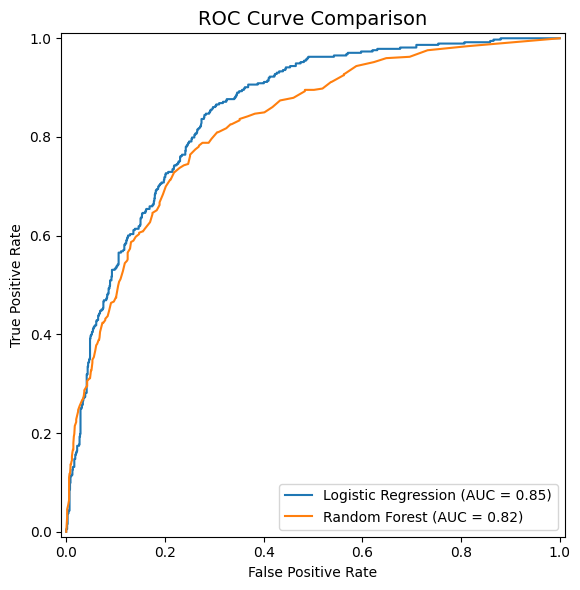

roc_curve.png saved


In [164]:
# ROC Curve (both models on same chart)

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')

ax.set_title('ROC Curve Comparison', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("roc_curve.png saved")

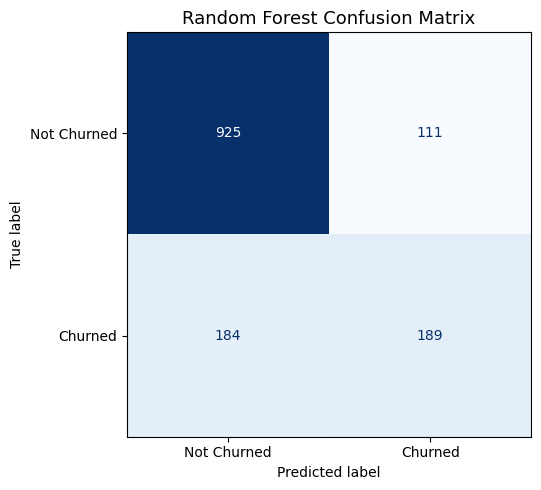

confusion_matrix.png saved


In [165]:
# Confusion Matrix

rf_preds = rf.predict(X_test)
cm = confusion_matrix(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("confusion_matrix.png saved")

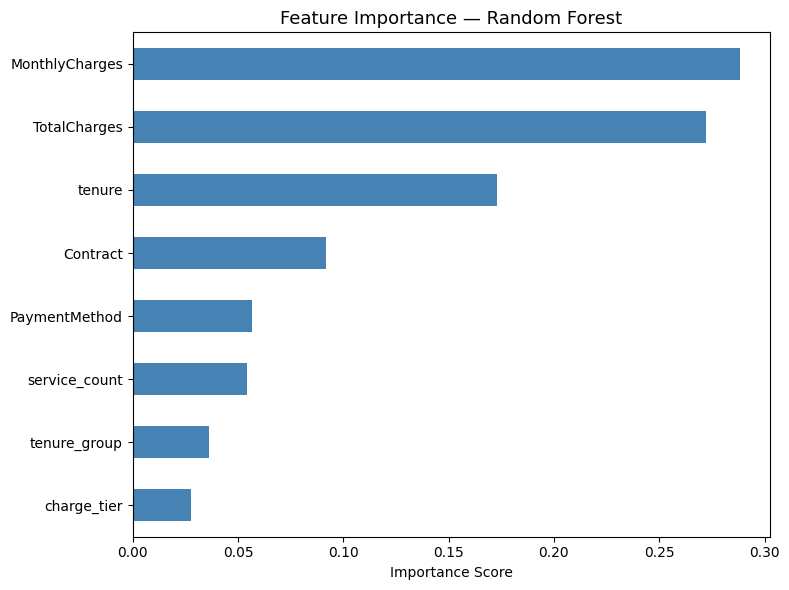

feature_importance.png saved


In [166]:
#  Feature Importance

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("feature_importance.png saved")

In [167]:
# Check all output files exist

import os

files_to_check = ['roc_curve.png', 'confusion_matrix.png', 'feature_importance.png']

for f in files_to_check:
    exists = os.path.exists(f)
    print(f"{f}: {'✓ Found' if exists else '✗ MISSING'}")

roc_curve.png: ✓ Found
confusion_matrix.png: ✓ Found
feature_importance.png: ✓ Found


In [168]:
# Download all charts

from google.colab import files

files.download('roc_curve.png')
files.download('confusion_matrix.png')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [169]:
# Final summary

print("=" * 45)
print("        CHURN PREDICTION — FINAL RESULTS")
print("=" * 45)
print(f"Dataset:              Telco Churn (7043 rows)")
print(f"Features used:        {X.shape[1]}")
print(f"Train/Test split:     80% / 20%")
print(f"Logistic Regression AUC:  {round(lr_auc, 4)}")
print(f"Random Forest AUC:        {round(rf_auc, 4)}")
print("=" * 45)
print("Output files: roc_curve.png, confusion_matrix.png,")
print("              feature_importance.png")
print("=" * 45)

        CHURN PREDICTION — FINAL RESULTS
Dataset:              Telco Churn (7043 rows)
Features used:        8
Train/Test split:     80% / 20%
Logistic Regression AUC:  0.8501
Random Forest AUC:        0.8214
Output files: roc_curve.png, confusion_matrix.png,
              feature_importance.png
